In [1]:
!pip install astroquery
import astroquery.vizier
from astroquery.vizier import Vizier
from astroquery.xmatch import XMatch
import astropy.units as u

vizier = Vizier(vizier_server = 'vizier.cfa.harvard.edu')
vizier.ROW_LIMIT = -1

# Overall Observing limits and constraints-------
PARALLAX_MIN = 80 #Distance limit, change as applicable
DEC_MIN= -20
HP_MAG_MAX= 13
MATCH_RADISU_ARCSEC= 5.0

MIRCX_H_MAX=8.0
MIRCX_LDD_OBS=0.5
MIRCX_LDD_IMG=2.0

SPICA_V_MAX= 5.0
SPICA_LDD_OBS= 0.2
SPICA_LDD_IMG= 0.8

#Obtaining Hipparcos Catelogue-----------------------
all_stars_query = vizier.query_constraints(
    catalog= "I/311/hip2",
    Plx=f">={PARALLAX_MIN}",
    DErad=f">= {DEC_MIN}",
    Hpmag =f"< {HP_MAG_MAX}")
hipparcos_table = all_stars_query[0]
print(f"Found {len(hipparcos_table)} canidate stars.")
print(hipparcos_table['RArad','DErad','Plx','Hpmag'])


#Crossmatching JSDC with Hipparcos---------------------------------------------
print ("Uploading Hipparcos table and crossmatching with JSDC...")

jsdc_matches = XMatch().query(
    hipparcos_table,
    'vizier:II/346/jsdc_v2',
    5 * u.arcsec, #Adding area of error instead of exact value
    colRA1 = 'RArad',
    colDec1= 'DErad'
)

#Funneling crossmatched data through SPICA and MIRC-X constraints---------------

print("Funneling crossmatched data through SPICA and MIRC-X filters...")

jsdc_matches['MIRCX_Resolvable'] = (jsdc_matches['Hmag']< MIRCX_H_MAX) &\
 (jsdc_matches['LDD']> MIRCX_LDD_OBS)

jsdc_matches['SPICA_Resolvable'] = (jsdc_matches['Vmag']< SPICA_V_MAX) &\
 (jsdc_matches['LDD']> SPICA_LDD_OBS)

jsdc_matches['MIRCX_Imagable'] =(jsdc_matches['LDD']> MIRCX_LDD_IMG)

jsdc_matches['SPICA_Imagable'] = (jsdc_matches['LDD']> SPICA_LDD_IMG)

# A star MUST be resolvable to be imageable
jsdc_matches['MIRCX_Imagable'] = (jsdc_matches['LDD']> MIRCX_LDD_IMG) & (jsdc_matches['MIRCX_Resolvable'] == True)

jsdc_matches['SPICA_Imagable'] = (jsdc_matches['LDD']> SPICA_LDD_IMG) & (jsdc_matches['SPICA_Resolvable'] == True)


#Printing final completed table-------------------------------------------------
columns_to_show = ['HIP', 'Plx','DErad','RArad','Hmag', 'Vmag', 'LDD',
                   'MIRCX_Resolvable', 'SPICA_Resolvable',
                   'MIRCX_Imagable', 'SPICA_Imagable']
final_output_table = jsdc_matches[columns_to_show]

# Printing final completed table
print("\n--- Final Results Table ---")
print(final_output_table)

# Saving the final table
final_output_table.write("full_star_results.csv", format="csv", overwrite=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.9 MB/s eta 0:00:00
Could not import regions, which is required for some of the functionalities of this module.
Found 219 canidate stars.
   RArad        DErad       Plx    Hpmag 
    deg          deg        mas     mag  
------------ ------------ ------- -------
  0.54018854  27.08448917   82.17  5.8735
  1.29233673  45.78693444   88.88  9.9952
  1.41782131  45.81245486   88.44  8.2899
  3.86527706 -16.13230909  200.53 11.4323
  4.58559072  44.02195596  278.76  8.1451
  8.11171915  67.23621557   99.35 10.3464
  9.84206096  21.25137382   90.42  6.0300
 12.09388796   5.28338880  134.14  5.8775
 12.27125307  57.81654753  167.98  3.5835
         ...          ...     ...     ...
341.70961233  44.33510785  195.22 10.2245
343.31731587 -14.26205823  213.28 10.1480
344.14764258  16.55412222  146.09  8.7104
346.66203145 -14.87240413  208.16 12.3750
348.31143192

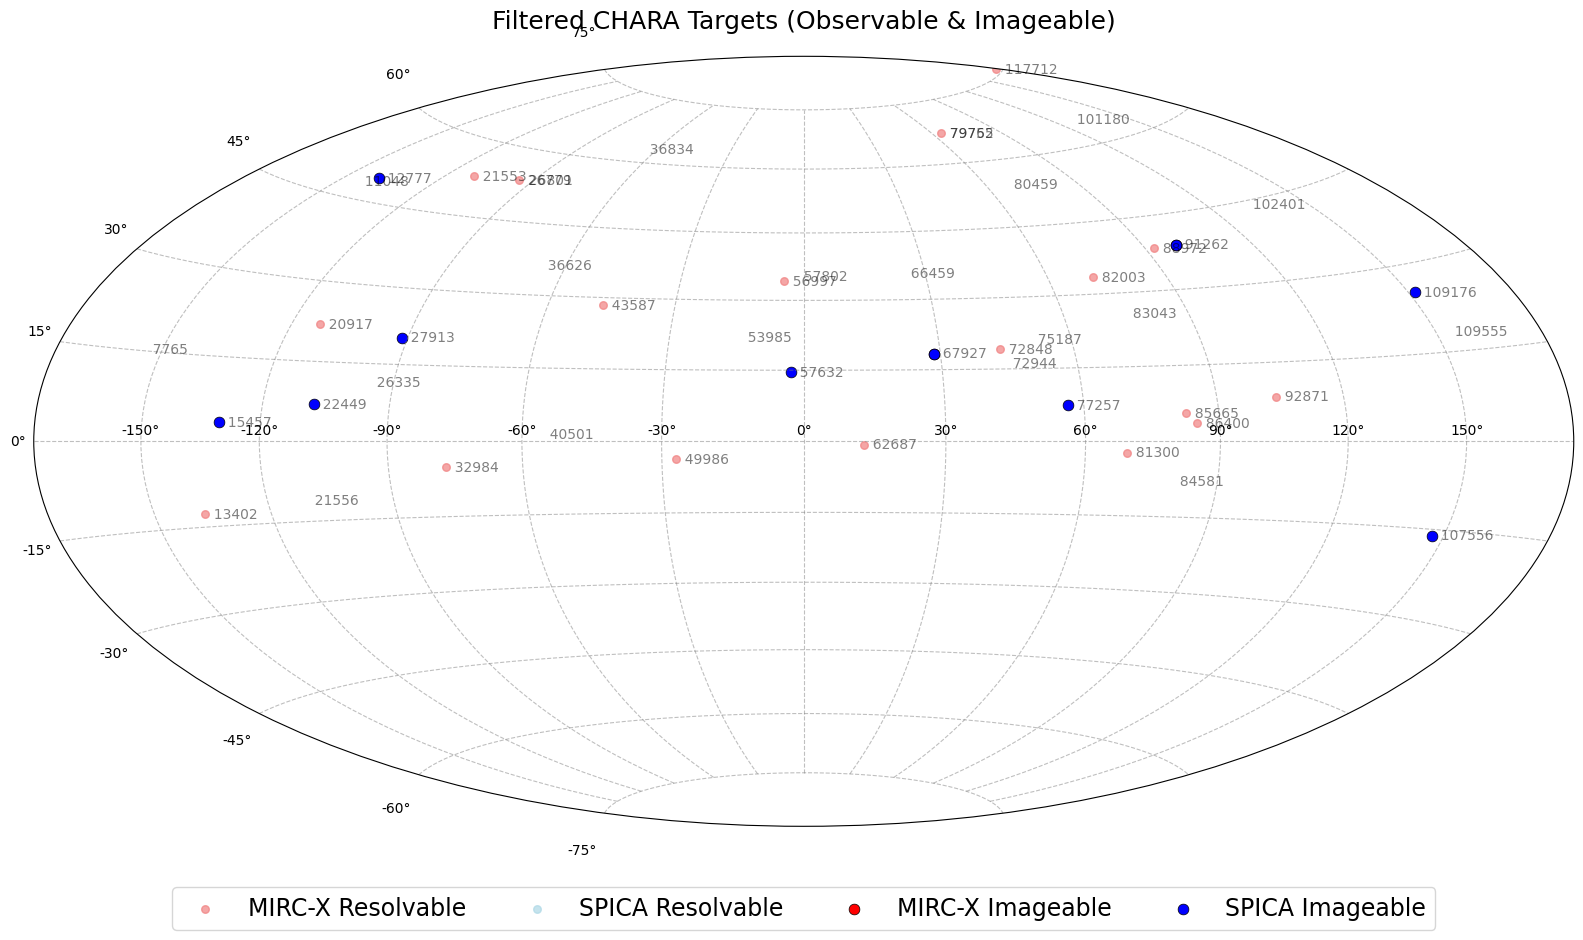

In [2]:
import matplotlib.pyplot as plt
import matplotlib.lines as Line2D
import numpy as np

# --- Detailed Skymap Projection of Found Stars---
ra = jsdc_matches['RArad'] * np.pi/180
dec = jsdc_matches['DErad'] * np.pi/180
mircx_col = jsdc_matches['MIRCX_Resolvable']
spica_col = jsdc_matches['SPICA_Resolvable']
mircx_col2 = jsdc_matches['MIRCX_Imagable']
spica_col2 = jsdc_matches['SPICA_Imagable']

# Create a mask that only keeps stars if they are resolvable by AT LEAST one instrument
resolvable_mask = (jsdc_matches['MIRCX_Resolvable'] == True) | (jsdc_matches['SPICA_Resolvable'] == True)

# Create a brand new, clean dataframe with only the good stars
str_targets = jsdc_matches[resolvable_mask]

# --- EXTRACT AND CONVERT COORDINATES ---
# Shift RA by pi to perfectly center it on the Hammer projection
ra_plot = (jsdc_matches['RArad'] * np.pi/180) - np.pi
dec_plot = jsdc_matches['DErad'] * np.pi/180

# --- CREATE INDIVIDUAL MASKS FOR PLOTTING ---
m_res = jsdc_matches['MIRCX_Resolvable'] == True
s_res = jsdc_matches['SPICA_Resolvable'] == True
m_img = jsdc_matches['MIRCX_Imagable'] == True
s_img = jsdc_matches['SPICA_Imagable'] == True

# --- Skymap construction ---
plt.figure(figsize=(20, 10))
plt.subplot(111, projection="hammer")

# Layer 1: Resolvables (Smaller, slightly transparent)
plt.scatter(ra_plot[m_res], dec_plot[m_res], color='lightcoral', label='MIRC-X Resolvable', s=30, alpha=0.7)
plt.scatter(ra_plot[s_res], dec_plot[s_res], color='lightblue', label='SPICA Resolvable', s=30, alpha=0.7)

# Layer 2: Imageables (Larger, bold colors with black borders to pop out)
#SPICA overlaps MIRC, comment out SPICA line to see MIRC-X Imagebale Stars
plt.scatter(ra_plot[m_img], dec_plot[m_img], color='red', label='MIRC-X Imageable', s=60, edgecolor='black', linewidth=0.5)
plt.scatter(ra_plot[s_img], dec_plot[s_img], color='blue', label='SPICA Imageable', s=60, edgecolor='black', linewidth=0.5)

# --- ADDING THE FAINT LABELS (HIP Identifier) ---
for x, y, hip_id in zip(ra_plot, dec_plot, jsdc_matches['HIP']):
    plt.text(x, y, f"  {hip_id}", fontsize=10, alpha=0.5, color='black', ha='left', va='center')

# Formatting
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=True, fontsize=17)
plt.title("Filtered CHARA Targets (Resolvable & Imageable)", fontsize=18, pad=20)
plt.grid(True, color='gray', linestyle='--', alpha=0.5)

# Remove the axis labels for a cleaner "presentation" look
#plt.xticks([])
#plt.yticks([])

plt.savefig('refined_skymap_spica.png', dpi=300, bbox_inches='tight')

plt.show()

In [3]:
from astroquery.utils.tap.core import Tap
from astropy.table import unique, Table, join
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table

#Accessing OiDB-------------------------------------
oidb = Tap (url='https://tap.jmmc.fr/vollt/tap/')

oidb_query = oidb.launch_job_async("SELECT * FROM oidb where oidb.facility_name = 'CHARA'")
oidb_results = oidb_query.get_results()

#Verifying OiDB Data with Simbad
simbad = Simbad()
simbad.add_votable_fields("ra")
simbad.add_votable_fields("dec")
simbad.add_votable_fields("plx_value")
star_list = list(oidb_results['target_name'])

#Printing shortlist for quick safety verification
short_list = star_list[:6]
print(short_list)

# --- PREPARE & CLEAN OIDB DATA ---
print("Cleaning OIDB data...")

# Handle column name variations (s_ra vs RA)
try:
    ra_col = 's_ra' if 's_ra' in oidb_results.colnames else 'RA'
    dec_col = 's_dec' if 's_dec' in oidb_results.colnames else 'DEC'
except AttributeError:
    # Fallback if names are totally different
    print(f"Could not find standard columns. Available: {oidb_results.colnames}")
    raise

# Filter out NaNs (Rows with missing coordinates)
# Creating a mask where RA or Dec is NOT valid, and keep the opposite
valid_rows = ~np.isnan(oidb_results[ra_col]) & ~np.isnan(oidb_results[dec_col])
oidb_clean = oidb_results[valid_rows]

print(f"Removed {len(oidb_results) - len(oidb_clean)} bad rows from OIDB. Remaining: {len(oidb_clean)}")

# Create SkyCoord for Observed Stars (using cleaned data)
c_observed = SkyCoord(
    ra=oidb_clean[ra_col],
    dec=oidb_clean[dec_col],
    unit=(u.deg, u.deg),
    frame='icrs'
)

# --- PREPARE CANDIDATE DATA ---
print("Processing Candidate coordinates...")

c_candidates = SkyCoord(
    ra=final_output_table['RArad'],
    dec=final_output_table['DErad'],
    unit=(u.deg, u.deg),
    frame='icrs'
)

# --- EXECUTE MATCH ---
print("Matching candidates to observed stars...")
idx, d2d, d3d = c_candidates.match_to_catalog_sky(c_observed)

# Define match threshold (e.g., 5 arcseconds)
max_sep = 5.0 * u.arcsec
constraint = d2d < max_sep

# --- STEP 4: TAG & SAVE RESULTS ---
final_output_table['Is_Observed'] = False
final_output_table['Is_Observed'][constraint] = True

# Record which OIDB star it matched with (using the cleaned table indices)
final_output_table['Matched_OIDB_ID'] = ''
try:
    # Try common name columns
    name_col = 'target_name' if 'target_name' in oidb_clean.colnames else 'target_ident'
    final_output_table['Matched_OIDB_ID'][constraint] = oidb_clean[name_col][idx[constraint]]
except KeyError:
    final_output_table['Matched_OIDB_ID'][constraint] = "Match_Found_No_Name"

# Filter for the List: Unobserved Stars by CHARA (OiDB)
unobs_targets = final_output_table[final_output_table['Is_Observed'] == False]

print("\n--- FINAL RESULTS ---")
print(f"Total Candidates: {len(final_output_table)}")
print(f"Already Observed: {np.sum(constraint)}")
print(f"Unobserved: {len(unobs_targets)}")

unobs_targets.write("unobserved_targets.csv", format="csv", overwrite=True)
print("Success! Saved unobserved targets to 'unobserved_targets.csv'")

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
['HD31293', 'HD_22049', 'HD_26912', 'HD_22049', 'Bet_Vic', 'HD_22049']
Cleaning OIDB data...
Removed 1 bad rows from OIDB. Remaining: 99533
Processing Candidate coordinates...
Matching candidates to observed stars...

--- FINAL RESULTS ---
Total Candidates: 48
Already Observed: 31
Unobserved: 17
Success! Saved unobserved targets to 'unobserved_targets.csv'


/tmp/ipykernel_3101/2646139161.py:79: StringTruncateWarning: truncated right side string(s) longer than 1 character(s) during assignment
  final_output_table['Matched_OIDB_ID'][constraint] = oidb_clean[name_col][idx[constraint]]


In [4]:

#---Creation of Observed and Unobserved list downloads for view----

unobserved_targets = final_output_table[
    (final_output_table['Is_Observed'] == False) &
    ((final_output_table['MIRCX_Resolvable'] == True) |
     (final_output_table['SPICA_Resolvable'] == True)|
     (final_output_table['MIRCX_Imagable'] == True)|
     (final_output_table['SPICA_Imagable'] == True))
]
observed_targets = final_output_table[
    (final_output_table['Is_Observed'] == True) &
    ((final_output_table['MIRCX_Resolvable'] == True) |
     (final_output_table['SPICA_Resolvable'] == True)|
     (final_output_table['MIRCX_Imagable'] == True)|
     (final_output_table['SPICA_Imagable'] == True))
]

unobserved_targets.sort('LDD', reverse=True)
observed_targets.sort('LDD', reverse=True)

#Select the most useful columns for your "Identifier" list
target_list_view_1 = unobserved_targets['HIP', 'Vmag', 'Hmag', 'LDD', 'MIRCX_Resolvable', 'SPICA_Resolvable','MIRCX_Imagable','SPICA_Imagable']
target_list_view_2 = observed_targets['HIP', 'Vmag', 'Hmag', 'LDD', 'MIRCX_Resolvable', 'SPICA_Resolvable','MIRCX_Imagable','SPICA_Imagable']

print(f"\n--- Extracted {len(unobserved_targets)} Unobserved Targets ---")
print(f"\n--- Extracted {len(observed_targets)} Observed Targets ---")
print(target_list_view_1)
print(target_list_view_2)

# Save this specific "Proposal List" to its own CSV
unobserved_targets.write("chara_unobs_targets.csv", format="csv", overwrite=True)
observed_targets.write("chara_obs_targets.csv", format="csv", overwrite=True)

print("Success! Saved lists to 'chara_unobs_targets.csv' and 'chara_obs_targets.csv'")


--- Extracted 3 Unobserved Targets ---

--- Extracted 25 Observed Targets ---
 HIP  Vmag  Hmag   LDD    ... SPICA_Resolvable MIRCX_Imagable SPICA_Imagable
      mag   mag    mas    ...                                               
----- ---- ----- -------- ... ---------------- -------------- --------------
26779 6.21 3.991 0.792491 ...            False          False          False
49986 9.26 5.258 0.621271 ...            False          False          False
85665 9.33 5.654 0.503649 ...            False          False          False
 HIP   Vmag  Hmag    LDD    ... SPICA_Resolvable MIRCX_Imagable SPICA_Imagable
       mag   mag     mas    ...                                               
------ ---- ------ -------- ... ---------------- -------------- --------------
 91262 0.03 -0.029 3.221385 ...             True           True           True
 67927 2.68  1.534 2.130985 ...             True           True           True
 22449 3.19  1.757 1.986537 ...             True          False 

In [5]:
# --- SIMBAD QUERY ---
#Used to confirm found literature (and quantity for refrence)

observed_targets.sort('HIP')

# Extract the strings in  numerical order
target_stars = ["HIP " + str(hip) for hip in observed_targets['HIP']]

custom_simbad = Simbad()
custom_simbad.add_votable_fields('biblio')

print(f"\nQuerying SIMBAD for publications for {len(target_stars)} targets...")

try:
    if len(target_stars) > 0:
        results = custom_simbad.query_objects(target_stars)

        for i, row in enumerate(results):
            star_name = target_stars[i]
            bibcode_string = row['biblio']

            if bibcode_string and str(bibcode_string).strip() != '--':
                bibcodes = str(bibcode_string).split('|')
                print(f"{star_name}: Found {len(bibcodes)} total papers.")
            else:
                print(f"{star_name}: 0 papers found.\n")

    else:
        print("No targets available to query.")

except Exception as e:
    print(f"SIMBAD query failed: {e}")


Querying SIMBAD for publications for 25 targets...
HIP 12777: Found 430 total papers.
HIP 13402: Found 143 total papers.
HIP 15457: Found 206 total papers.
HIP 20917: Found 264 total papers.
HIP 21553: Found 950 total papers.
HIP 22449: Found 225 total papers.
HIP 27913: Found 603 total papers.
HIP 32984: Found 898 total papers.
HIP 43587: Found 243 total papers.
HIP 56997: Found 1225 total papers.
HIP 57632: Found 284 total papers.
HIP 62687: Found 560 total papers.
HIP 67927: Found 469 total papers.
HIP 72848: Found 656 total papers.
HIP 77257: Found 606 total papers.
HIP 79755: Found 247 total papers.
HIP 81300: Found 735 total papers.
HIP 82003: Found 290 total papers.
HIP 86400: Found 528 total papers.
HIP 88972: Found 322 total papers.
HIP 91262: Found 621 total papers.
HIP 92871: Found 214 total papers.
HIP 107556: Found 194 total papers.
HIP 109176: Found 482 total papers.
HIP 117712: Found 2794 total papers.


In [11]:
from astroquery.simbad import Simbad
from astroquery.nasa_ads import ADS
import pandas as pd
import time
import re

# --- NASA ADS & SIMBAD ---
ADS.TOKEN = ''  # <--- Put your active NASA ADS token here
ADS.ADS_FIELDS = ['bibcode', 'title', 'abstract', 'author', 'keyword']

#Keyword-based search, add or subtract both target(used to confirm hits)
#and junk (abstracts or titles containing these are skipped) keywords as applicable
target_keywords = ["chara", "mirc", "spica", "interferometry"]
junk_words = ["vizier", "data release", "catalog", "survey of", "gaiadr"]

custom_simbad = Simbad()
custom_simbad.add_votable_fields('biblio')

#Saving hits to empty set
known_matches = {}
known_rejections = set()
print("--- Loading Targets from Previous Cell ---")


try:
    # Pulling 'observed_targets' Astropy Table
    # generated in previous code cell.
    target_stars = []
    for hip_val in observed_targets['HIP']:
        clean_name = str(hip_val).strip()
        if "HIP" not in clean_name.upper():
            clean_name = f"HIP {clean_name}"
        target_stars.append(clean_name)

    print(f"Success: Loaded {len(target_stars)} observable targets directly from memory.")
    print("Beginning Literature Mining... (This may take several minutes)\n")

except NameError:
    print("ERROR: 'observed_targets' is not defined. Please ensure you have run the cross-matching cell first!")
    target_stars = []


# --- LITERATURE MINER ---
for count, star_name in enumerate(target_stars, 1):
    print(f"\n[{count}/{len(target_stars)}] Querying SIMBAD for {star_name}...")
    try:
        # Query safely, one star at a time, slow but avoids crashing
        simbad_table = custom_simbad.query_object(star_name)

        if simbad_table is None or len(simbad_table) == 0:
            print(f"  [-] Not found in SIMBAD database.")
            continue

        row = simbad_table[0]
        bibcode_string = row['biblio']

        if bibcode_string and str(bibcode_string).strip() != '--':
            bibcodes = str(bibcode_string).split('|')

#Start year set to 2018 to coincide with the opperation of both MIRC-X and SPICA, change as applicable
            START_YEAR = 2018
            modern_bibcodes = [bib.strip() for bib in bibcodes if len(bib.strip()) >= 4 and bib.strip()[:4].isdigit() and int(bib.strip()[:4]) >= START_YEAR]

            found_flag = False
            if modern_bibcodes:
                print(f"  Scanning {len(modern_bibcodes)} modern papers (>= {START_YEAR})...")

            for bib in modern_bibcodes:
                if bib in known_matches:
                    if star_name not in known_matches[bib]['Target_Stars']:
                        known_matches[bib]['Target_Stars'].append(star_name)
                        print(f"  [CACHE HIT!] Added {star_name} to existing paper {bib}")
                    found_flag = True
                    continue

                if bib in known_rejections:
                    continue

                retries = 0
                success = False

                while retries < 3 and not success:
                    try:
                        ads_results = ADS.query_simple(f"bibcode:{bib}")

                        if ads_results and len(ads_results) > 0:
                            title = str(ads_results['title'][0]).lower()

                            #Catalog Removal
                            if any(junk in title for junk in junk_words):
                                known_rejections.add(bib)
                                success = True
                                continue

                            abstract = str(ads_results['abstract'][0]).lower()

                            # Extract user keywords
                            kw_data = ads_results['keyword'][0] if 'keyword' in ads_results.keys() else []
                            if hasattr(kw_data, '__iter__') and not isinstance(kw_data, str):
                                kw_string = " ".join([str(k) for k in kw_data]).lower()
                            else:
                                kw_string = str(kw_data).lower()

                            # Combine Title, Abstract, AND user Keywords
                            search_blob = title + " " + abstract + " " + kw_string

                            matches = [k.upper() for k in target_keywords if re.search(rf'\b{k}\b', search_blob)]

                            if matches:
                                found_flag = True
                                author_list = ads_results['author'][0]
                                full_authors_string = ", ".join([str(a) for a in author_list]) if hasattr(author_list, '__iter__') and not isinstance(author_list, str) else str(author_list)

                                print(f"    [NEW MATCH!] {bib}")
                                print(f"       Title: {str(ads_results['title'][0])[:80]}...")
                                print(f"       Found: {', '.join(matches)}")

                                known_matches[bib] = {
                                    'Target_Stars': [star_name],
                                    'Bibcode': bib,
                                    'Title': str(ads_results['title'][0]),
                                    'Authors': full_authors_string,
                                    'Keywords_Found': ", ".join(matches)
                                }
                            else:
                                known_rejections.add(bib)
                        else:
                            known_rejections.add(bib)

                        success = True
                        time.sleep(0.3)

                    except Exception as loop_error:
                        error_text = str(loop_error)
                        if '502' in error_text or '503' in error_text or '429' in error_text:
                            retries += 1
                            print(f"    [!] Server busy for {bib}. Retrying in 5s... (Attempt {retries}/3)")
                            time.sleep(5)
                        else:
                            known_rejections.add(bib)
                            break

            if not found_flag:
                print(f"  [-] No specific target matches found for {star_name}.")
        else:
            print(f"  [-] 0 papers found in SIMBAD.")

        # Small delay to prevent hammering SIMBAD too fast, change as applicable
        time.sleep(0.2)

    except Exception as e:
        print(f"  [!] Error processing {star_name}: {e}")

# --- EXPORT TO CSV ---
print("\n=== PIPELINE COMPLETE ===")
if known_matches:
    # Flatten the Target_Stars list into a clean string for the CSV
    for bib in known_matches:
        known_matches[bib]['Target_Stars'] = ", ".join(known_matches[bib]['Target_Stars'])

    df_final = pd.DataFrame.from_dict(known_matches, orient='index')

    # Save the dataframe to a CSV file
    output_filename = "CHARA_Literature_Catalog.csv"
    df_final.to_csv(output_filename, index=False)

    print(f"Success! Found {len(df_final)} relevant papers.")
    print(f"Saved master spreadsheet to: {output_filename}")
else:
    print("No relevant papers found for the dataset.")

--- Loading Targets from Previous Cell ---
Success: Loaded 25 observable targets directly from memory.
Beginning Literature Mining... (This may take several minutes)


[1/25] Querying SIMBAD for HIP 12777...
  Scanning 52 modern papers (>= 2018)...
    [NEW MATCH!] 2018MNRAS.473.3608A
       Title: ['Predicting stellar angular diameters from V, I<SUB>C</SUB>, H and K photometry...
       Found: INTERFEROMETRY
    [NEW MATCH!] 2020A&A...640A...2S
       Title: ['Precise calibration of the dependence of surface brightness-colour relations o...
       Found: CHARA


KeyboardInterrupt: 